In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')


import shap
import lime
import lime.lime_tabular
from anchor import anchor_tabular
import dice_ml


from sklearn.inspection import permutation_importance, PartialDependenceDisplay

## Chargement des données et des modèles
Chargement des données prétraitées et des 3 modèles les plus performants 
issus du notebook 03 : Random Forest (0.9007), Decision Tree (0.8649) et DNN (0.8272).
Ces modèles sont utilisés pour l'application des méthodes XAI.

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test_binary = pd.read_csv('../data/processed/y_test_binary.csv').squeeze()
y_train_binary = pd.read_csv('../data/processed/y_train_binary.csv').squeeze()

feature_names = X_train.columns.tolist()
print(f'Features : {feature_names}')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')

with open('../models/random_forest_binary.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../models/decision_tree_binary.pkl', 'rb') as f:
    dt_model = pickle.load(f)

with open('../models/dnn_binary.pkl', 'rb') as f:
    dnn_model = pickle.load(f)

models = {
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'DNN': dnn_model
}

Features : ['posx', 'posy', 'posx_n', 'posy_n', 'spdx', 'spdy', 'spdx_n', 'spdy_n', 'aclx', 'acly', 'aclx_n', 'acly_n', 'hedx', 'hedy', 'hedx_n', 'hedy_n']
X_train shape : (2555846, 16)
X_test shape  : (638962, 16)


## SHAP Global
SHAP (SHapley Additive exPlanations) est une méthode XAI basée sur la théorie des jeux de Shapley. Elle calcule la contribution de chaque feature à la prédiction du modèle. Ici on applique SHAP de manière globale sur 100 observations de X_test pour identifier les features les plus importantes pour chaque modèle. Pour Random Forest et Decision Tree, on utilise TreeExplainer (optimisé pour les 
arbres de décision). Pour DNN, on utilise KernelExplainer (méthode générique). Les résultats sont sauvegardés dans shap_values_dict.pkl.

Calcul SHAP pour Random Forest...
  Type: liste, len=2, shape[0]=(100, 16)


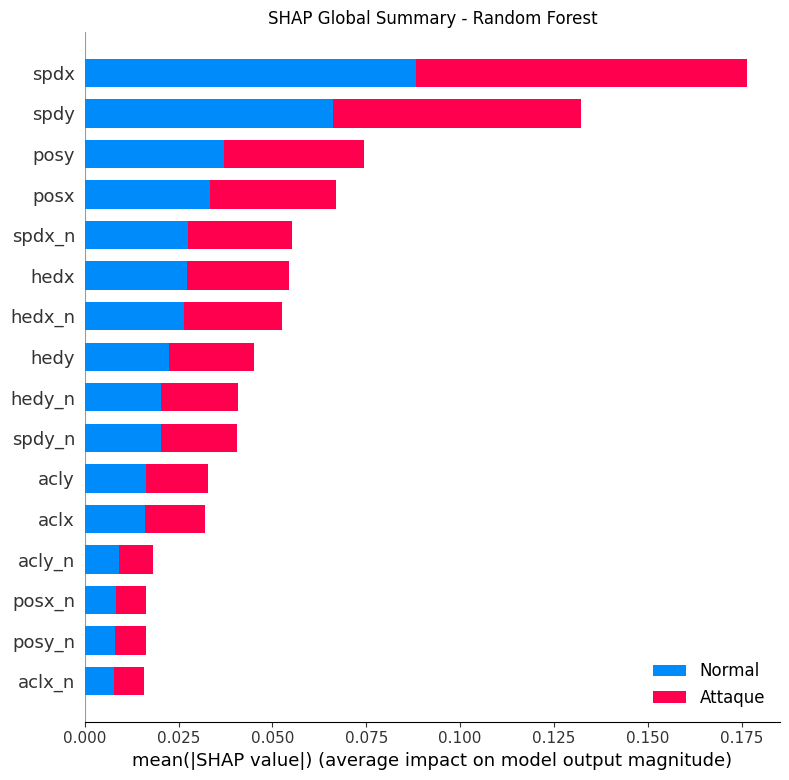

Calcul SHAP pour Decision Tree...
  Type: liste, len=2, shape[0]=(100, 16)


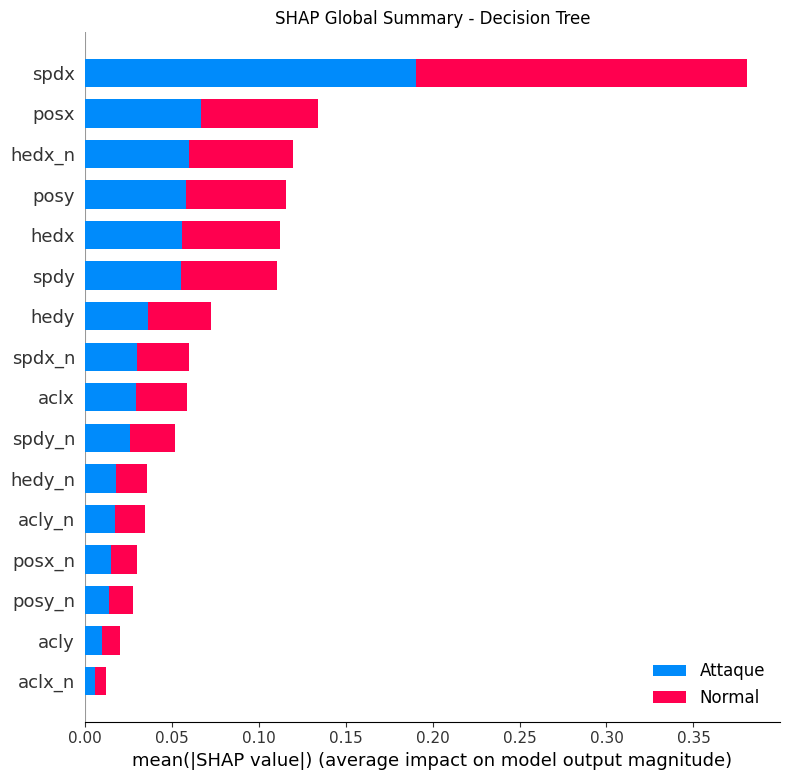

Calcul SHAP pour DNN...


100%|██████████| 100/100 [00:05<00:00, 16.72it/s]


  Type: liste, len=2, shape[0]=(100, 16)


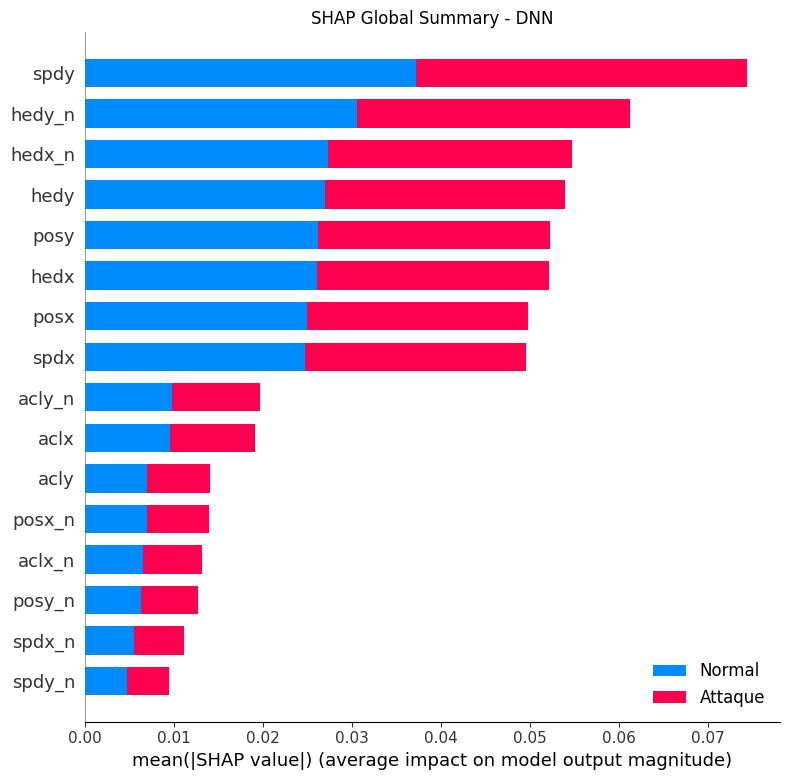

In [ ]:
shap_values_dict = {}

for name, model in models.items():
    print(f'Calcul SHAP pour {name}...')
    
    
    X_sample = X_test.sample(n=100, random_state=42)
    
    if name == 'DNN':
        X_background = shap.sample(X_train, 100)
        explainer = shap.KernelExplainer(model.predict_proba, X_background)
        shap_values = explainer.shap_values(X_sample, nsamples=100)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    
    shap_values_dict[name] = shap_values
    
    if isinstance(shap_values, list):
        print(f'  Type: liste, len={len(shap_values)}, shape[0]={shap_values[0].shape}')
    else:
        print(f'  Type: array, shape={shap_values.shape}')
    
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_names,
        plot_type="bar",
        class_names=['Normal', 'Attaque'],
        show=False
    )
    plt.title(f'SHAP Global Summary - {name}')
    plt.tight_layout()
    plt.savefig(f'../figures/shap_bar_{name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    with open('../models/shap_values_dict.pkl', 'wb') as f:
     pickle.dump(shap_values_dict, f)

## SHAP Local
Contrairement au SHAP Global, SHAP Local explique la prédiction du modèle pour une observation individuelle. Pour chaque modèle, on sélectionne 3 cas représentatifs :
- Vrai Normal : message normal correctement classifié
- Vrai Attaque : message d'attaque correctement classifié  
- Faux Positif : message normal incorrectement classifié comme attaque
Le waterfall plot montre la contribution de chaque feature à la décision finale.
Les valeurs numériques sont sauvegardées dans shap_local_dict.pkl pour être 
utilisées dans le notebook LLM.

SHAP Local pour Random Forest...


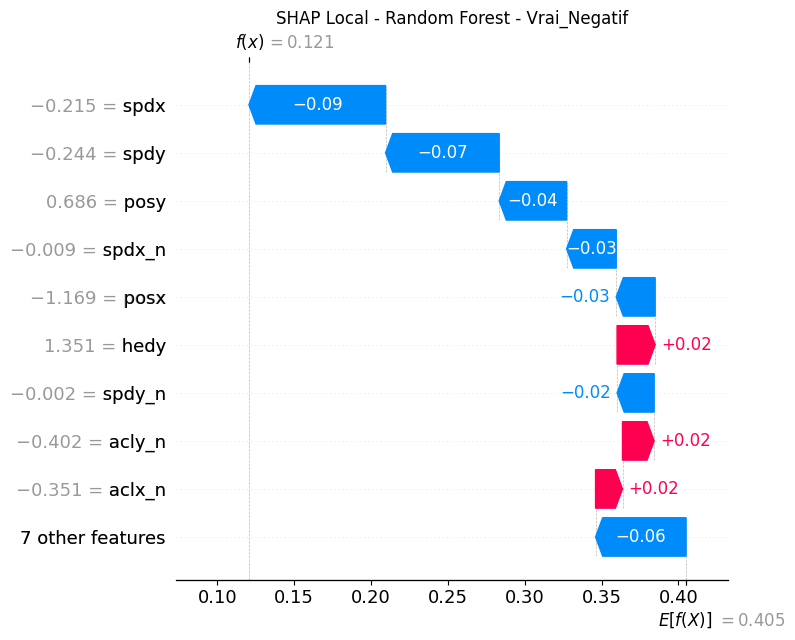

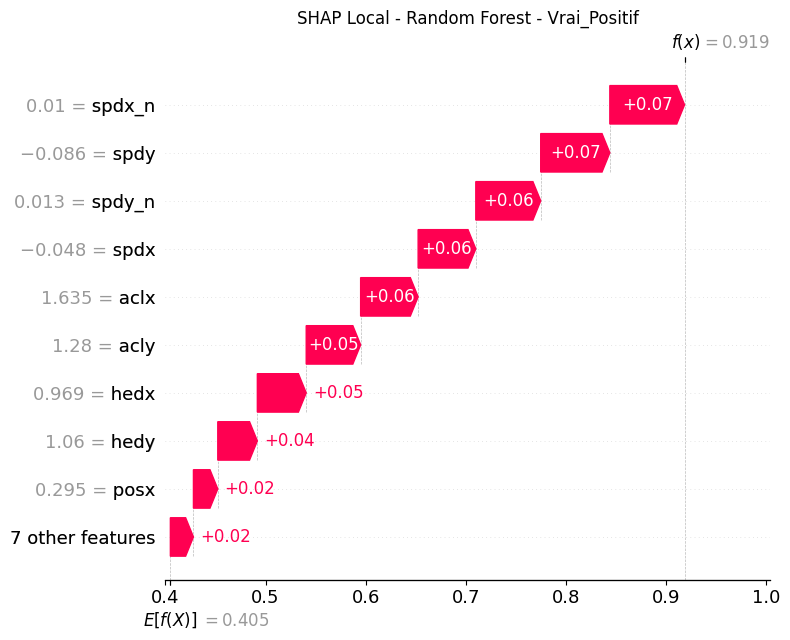

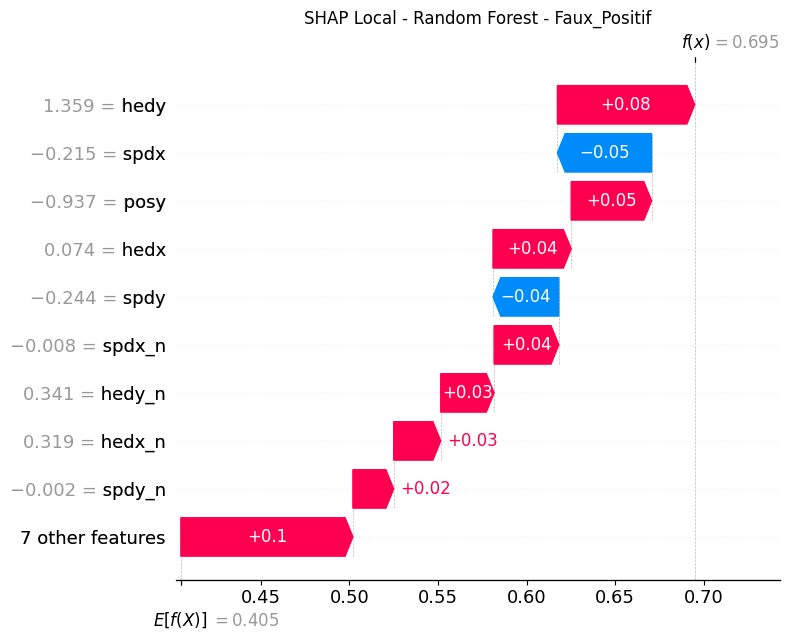

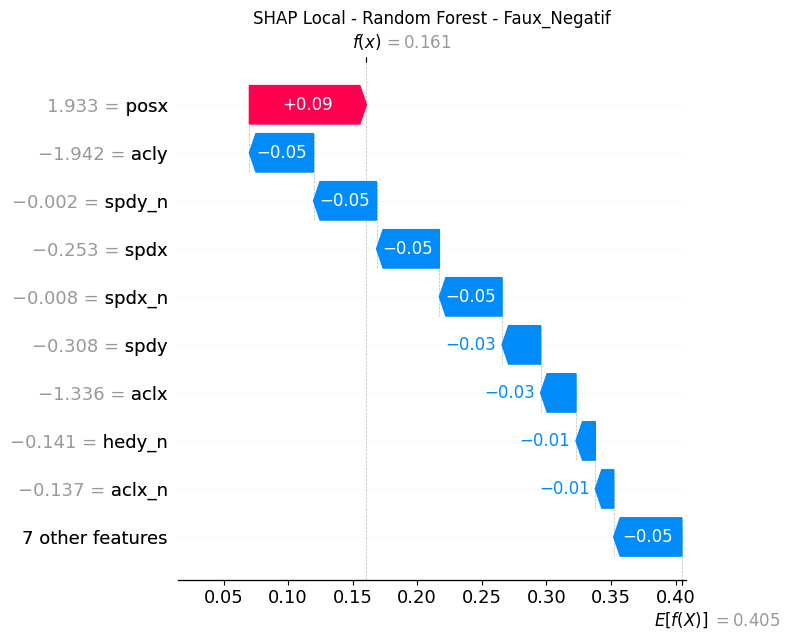

SHAP Local pour Decision Tree...


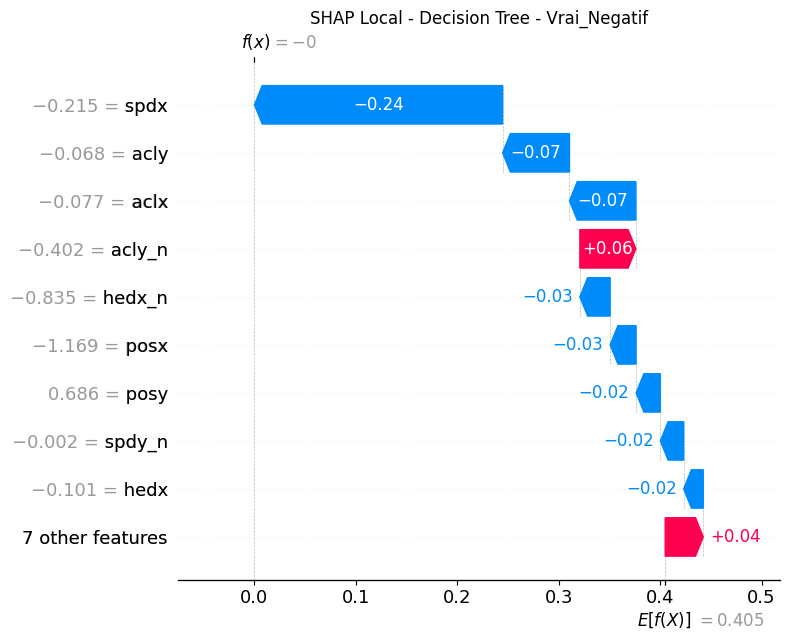

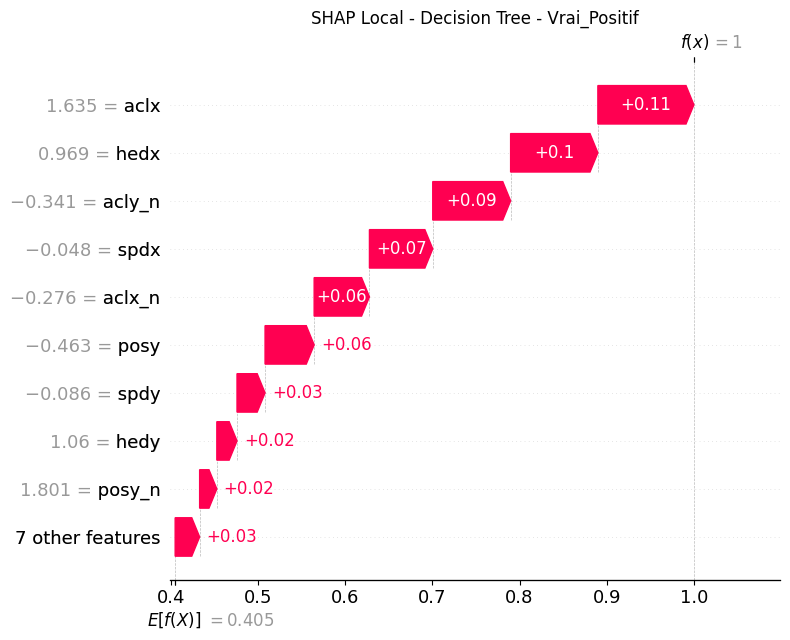

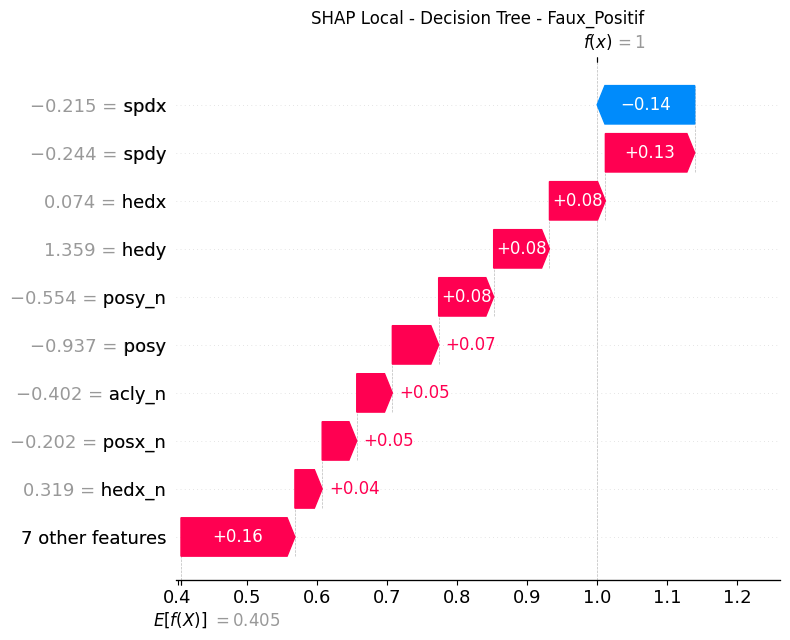

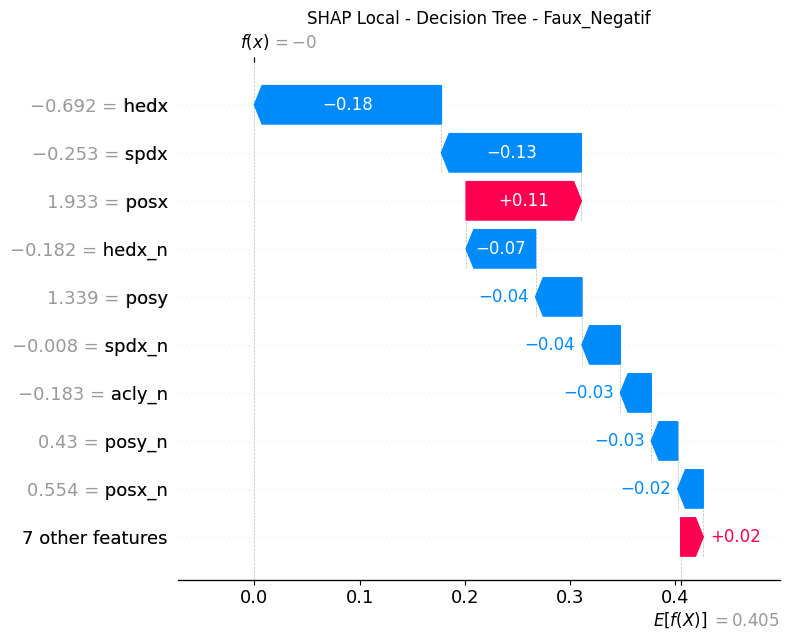

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


SHAP Local pour DNN...


100%|██████████| 1/1 [00:00<00:00,  3.67it/s]


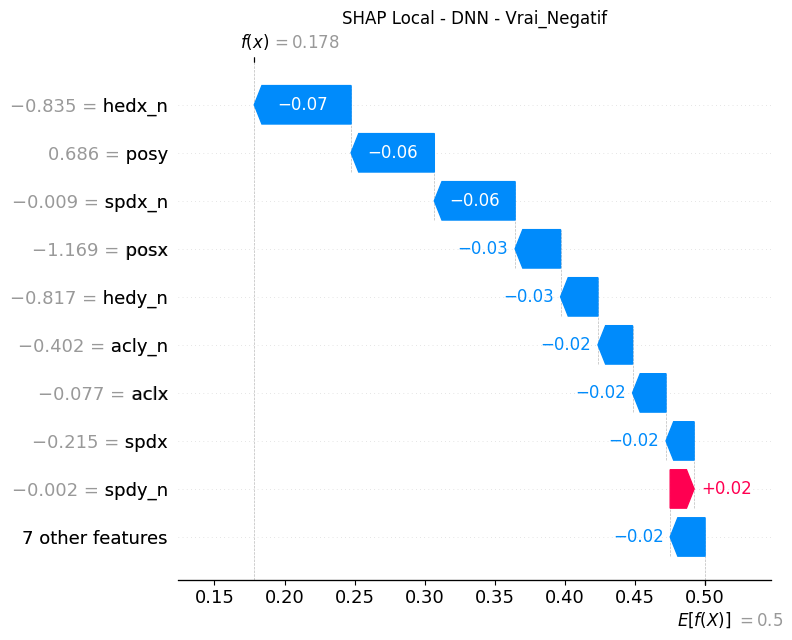

100%|██████████| 1/1 [00:00<00:00,  3.78it/s]


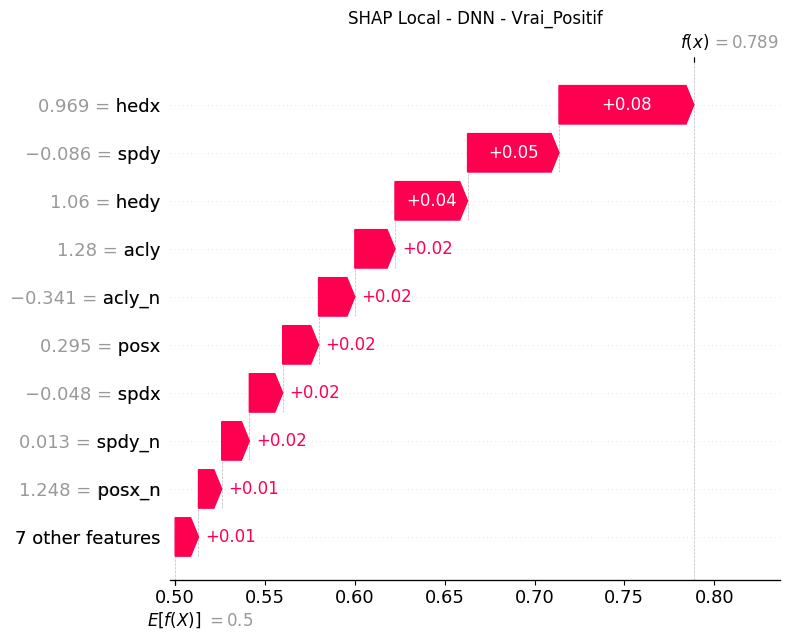

100%|██████████| 1/1 [00:00<00:00,  3.39it/s]


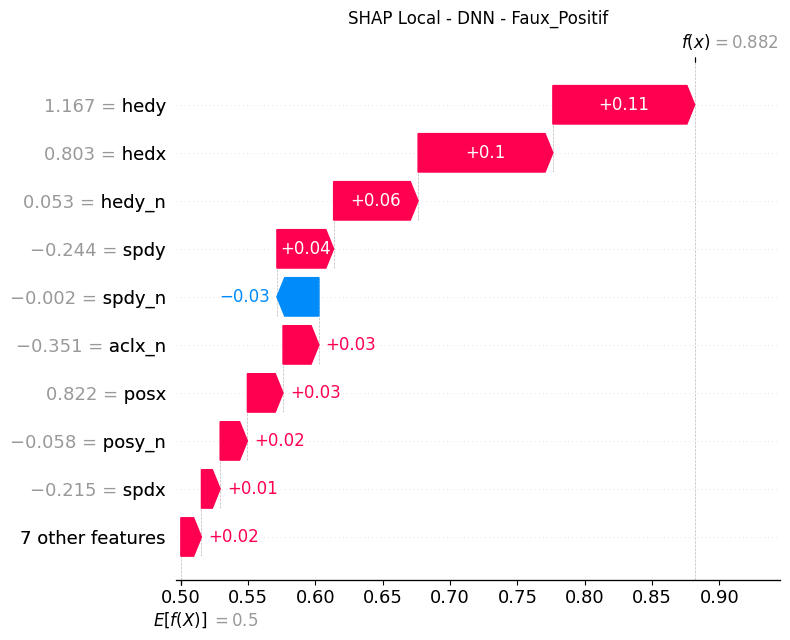

100%|██████████| 1/1 [00:00<00:00,  3.18it/s]


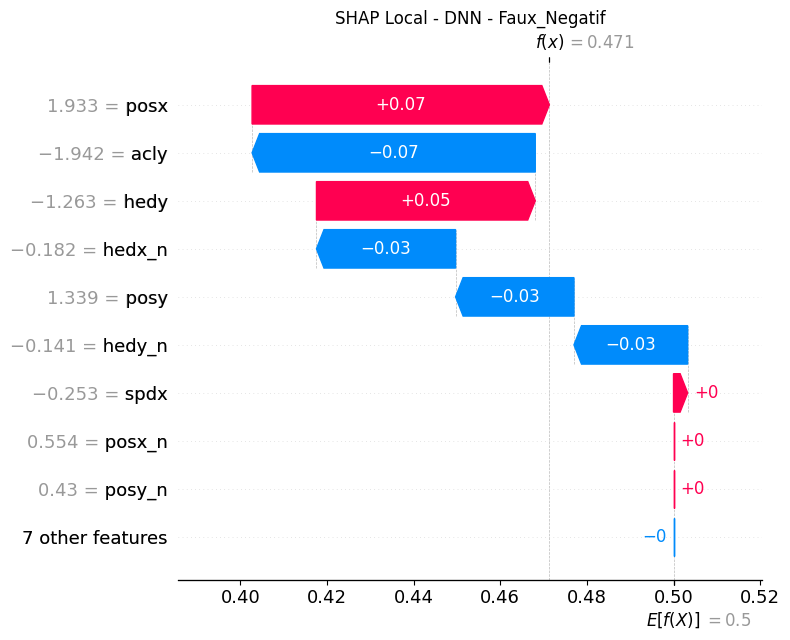

In [ ]:
shap_local_dict = {}

for name, model in models.items():
    print(f'SHAP Local pour {name}...')
    shap_local_dict[name] = {}
    
    if name != 'DNN':
        explainer = shap.TreeExplainer(model)
        ev = explainer.expected_value
        base_val = float(ev[1]) if isinstance(ev, (list, np.ndarray)) else float(ev)
    else:
        X_background = shap.sample(X_train, 200)  
        explainer = shap.KernelExplainer(model.predict_proba, X_background)
        base_val = 0.5
    
    X_local = X_test.sample(n=1000, random_state=42)
    y_local = y_test_binary.loc[X_local.index]
    y_pred_local = model.predict(X_local)
    
    observations = {
        'Vrai_Negatif': X_local[(y_pred_local == 0) & (y_local.values == 0)].iloc[[0]],
        'Vrai_Positif': X_local[(y_pred_local == 1) & (y_local.values == 1)].iloc[[0]],
        'Faux_Positif': X_local[(y_pred_local == 1) & (y_local.values == 0)].iloc[[0]],
        'Faux_Negatif': X_local[(y_pred_local == 0) & (y_local.values == 1)].iloc[[0]]
    }
    
    for obs_name, obs in observations.items():
        if name != 'DNN':
            sv = explainer.shap_values(obs)
            sv_plot = sv[1][0] if isinstance(sv, list) else sv[0]
        else:
            sv = explainer.shap_values(obs, nsamples=500)
            sv_plot = sv[1][0]
        
        shap_local_dict[name][obs_name] = {
            'shap_values': sv_plot,
            'base_value': base_val,
            'data': obs.values[0],
            'prediction': model.predict_proba(obs)[0]
        }
        
        shap.waterfall_plot(
            shap.Explanation(
                values=sv_plot,
                base_values=base_val,
                data=obs.values[0],
                feature_names=feature_names
            ),
            show=False
        )
        plt.title(f'SHAP Local - {name} - {obs_name}')
        plt.tight_layout()
        plt.savefig(f'../figures/shap_local_{name.lower().replace(" ", "_")}_{obs_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

with open('../models/shap_local_dict.pkl', 'wb') as f:
    pickle.dump(shap_local_dict, f)


LIME pour Random Forest...


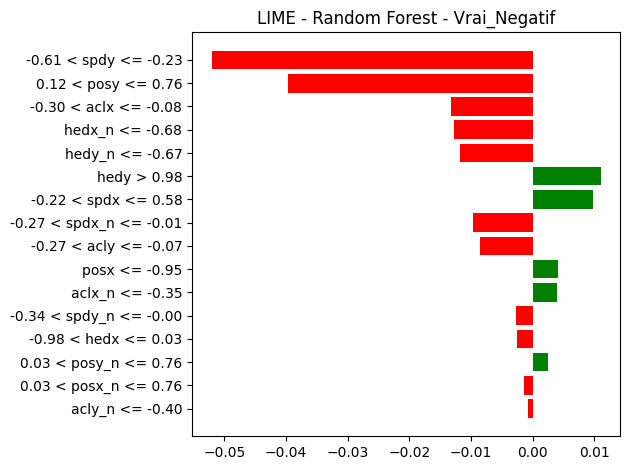

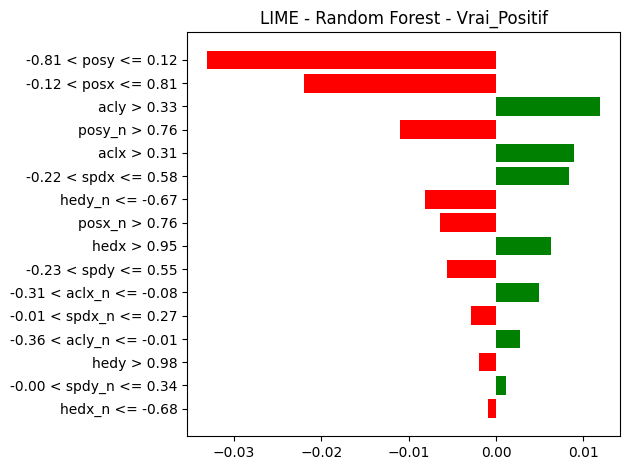

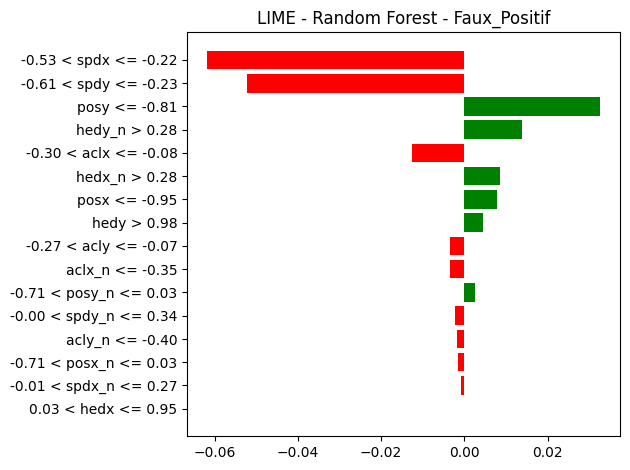

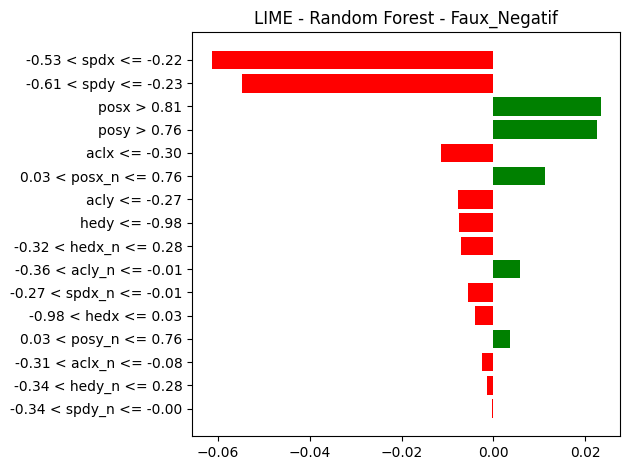

LIME pour Decision Tree...


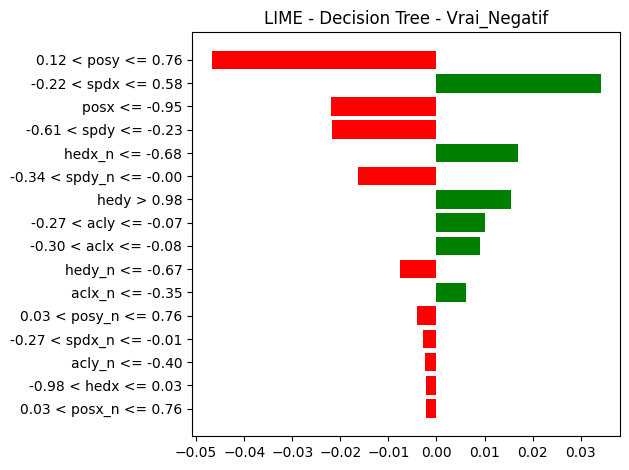

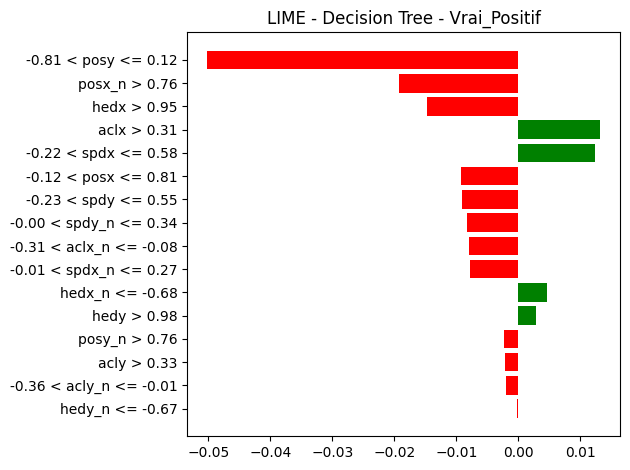

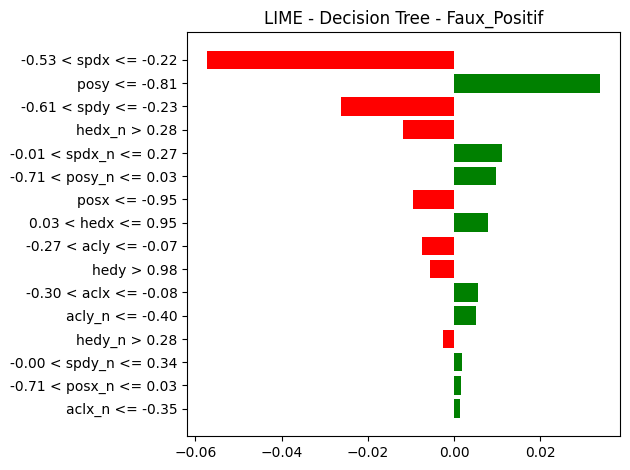

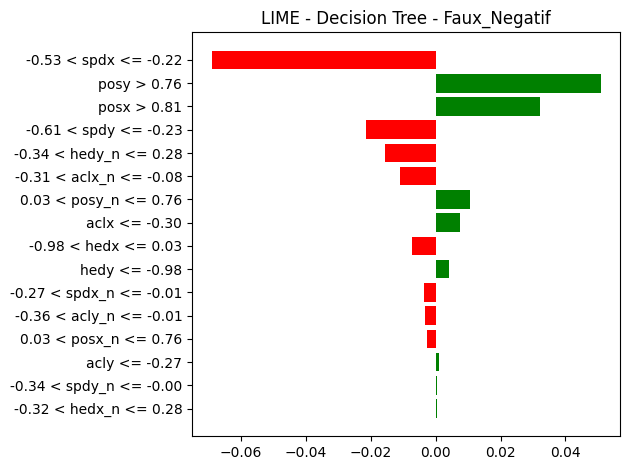

LIME pour DNN...


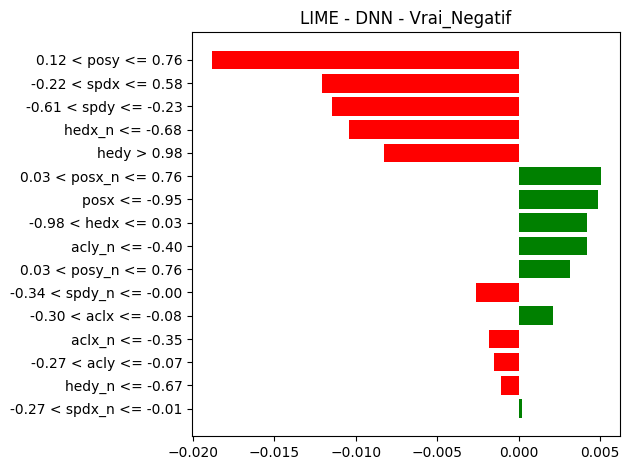

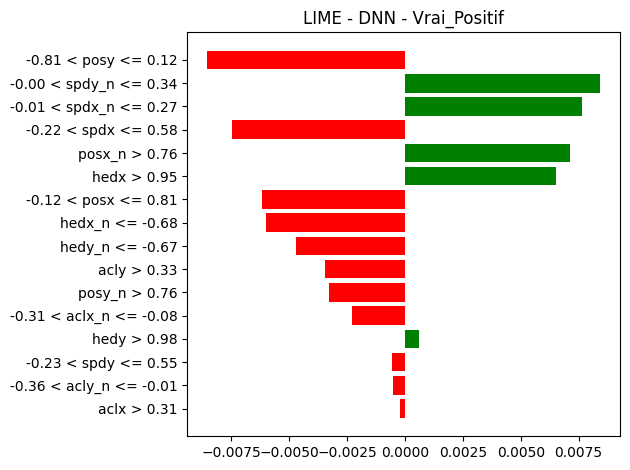

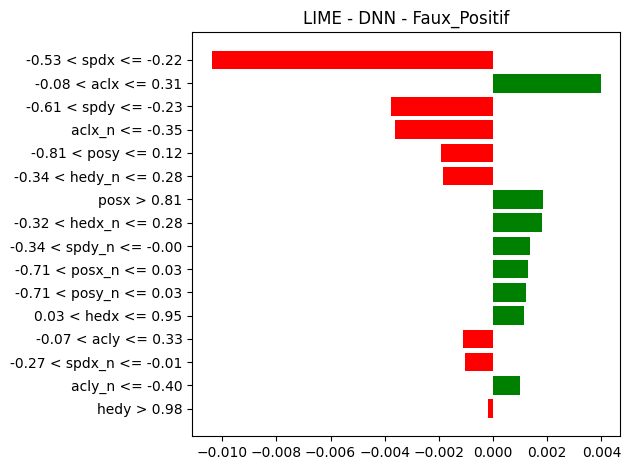

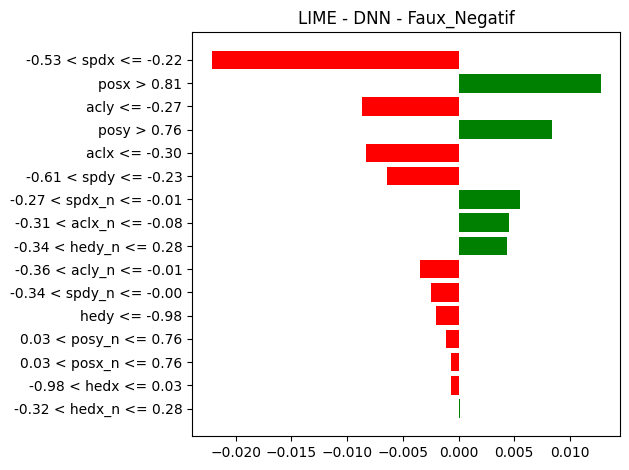

In [5]:

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=['Normal', 'Attaque'],
    mode='classification',
    random_state=42
)

lime_results = {}

for name, model in models.items():
    print(f'LIME pour {name}...')
    lime_results[name] = {}
    
  
    X_local = X_test.sample(n=1000, random_state=42)
    y_local = y_test_binary.loc[X_local.index]
    y_pred_local = model.predict(X_local)
    
    observations = {
        'Vrai_Negatif': X_local[(y_pred_local == 0) & (y_local.values == 0)].iloc[[0]],
        'Vrai_Positif': X_local[(y_pred_local == 1) & (y_local.values == 1)].iloc[[0]],
        'Faux_Positif': X_local[(y_pred_local == 1) & (y_local.values == 0)].iloc[[0]],
        'Faux_Negatif': X_local[(y_pred_local == 0) & (y_local.values == 1)].iloc[[0]]
    }
    
    for obs_name, obs in observations.items():
        exp = lime_explainer.explain_instance(
            obs.values[0],
            model.predict_proba,
            num_features=len(feature_names)
        )
        
        lime_results[name][obs_name] = exp
        
        fig = exp.as_pyplot_figure()
        plt.title(f'LIME - {name} - {obs_name}')
        plt.tight_layout()
        plt.savefig(f'../figures/lime_{name.lower().replace(" ", "_")}_{obs_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

lime_numeric = {}
for name in lime_results:
    lime_numeric[name] = {}
    for obs_name, exp in lime_results[name].items():
        lime_numeric[name][obs_name] = {
            'features': exp.as_list(),
            'prediction': exp.predict_proba
        }

with open('../models/lime_results.pkl', 'wb') as f:
    pickle.dump(lime_numeric, f)
       

Permutation Importance pour Random Forest...
  Temps : 99s (1.7 min)


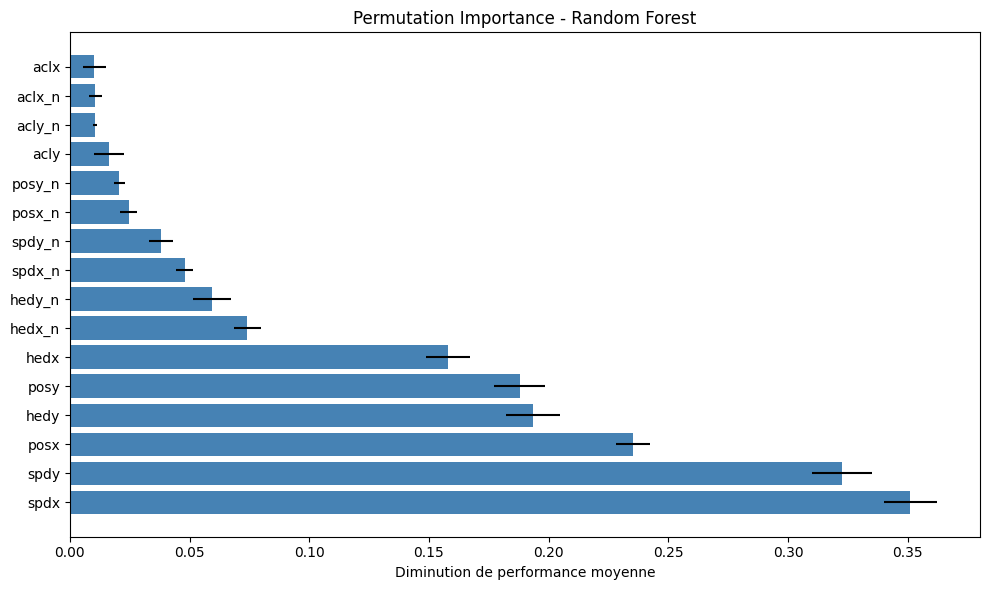

Permutation Importance pour Decision Tree...
  Temps : 2s (0.0 min)


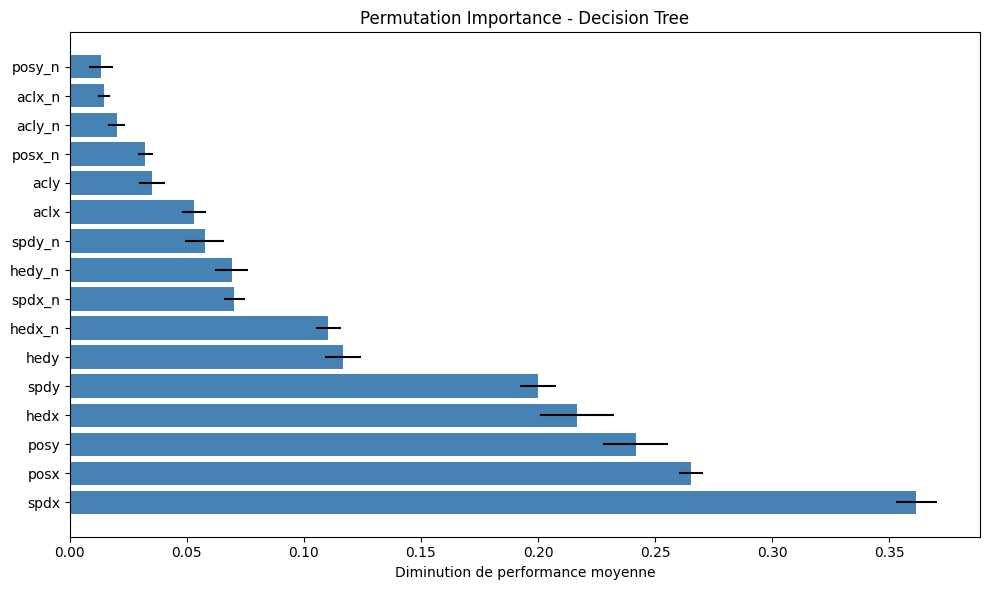

Permutation Importance pour DNN...
  Temps : 0s (0.0 min)


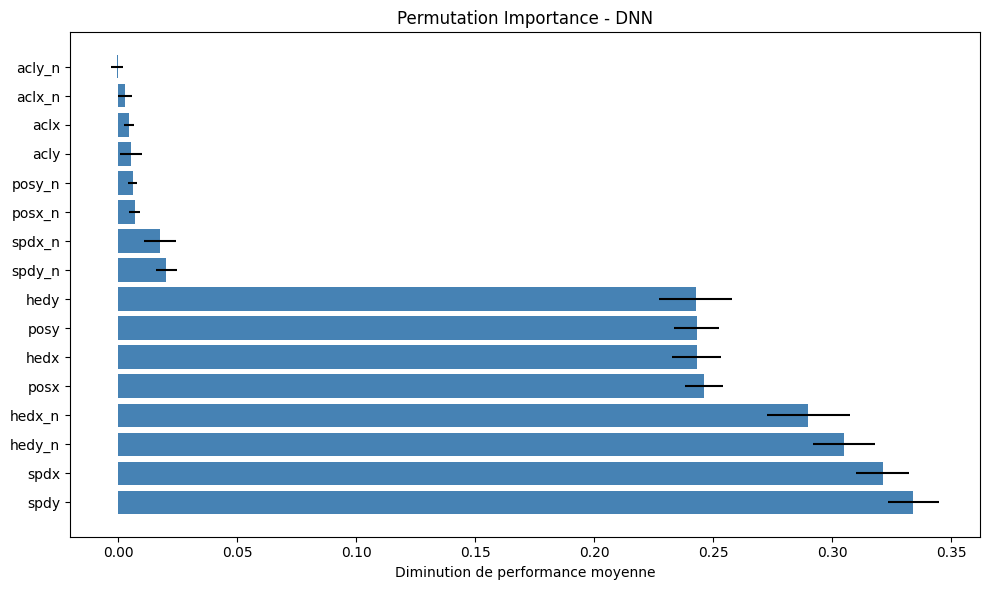

In [ ]:
import time
perm_results = {}

for name, model in models.items():
    print(f'Permutation Importance pour {name}...')
    start = time.time()
    
    X_perm = X_test.sample(n=1000, random_state=42)
    y_perm = y_test_binary.loc[X_perm.index]
    
    result = permutation_importance(
        model, X_perm, y_perm,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    
    perm_results[name] = result
    elapsed = time.time() - start
    print(f'  Temps : {elapsed:.0f}s ({elapsed/60:.1f} min)')
    
    
    sorted_idx = result.importances_mean.argsort()[::-1]
    
  
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        [feature_names[i] for i in sorted_idx],
        result.importances_mean[sorted_idx],
        xerr=result.importances_std[sorted_idx],
        color='steelblue'
    )
    ax.set_xlabel('Diminution de performance moyenne')
    ax.set_title(f'Permutation Importance - {name}')
    plt.tight_layout()
    plt.savefig(f'../figures/perm_importance_{name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

perm_numeric = {}
for name, result in perm_results.items():
    perm_numeric[name] = {
        'importances_mean': result.importances_mean.tolist(),
        'importances_std': result.importances_std.tolist(),
        'feature_names': feature_names
    }

with open('../models/perm_results.pkl', 'wb') as f:
    pickle.dump(perm_numeric, f)

PDP pour Random Forest...


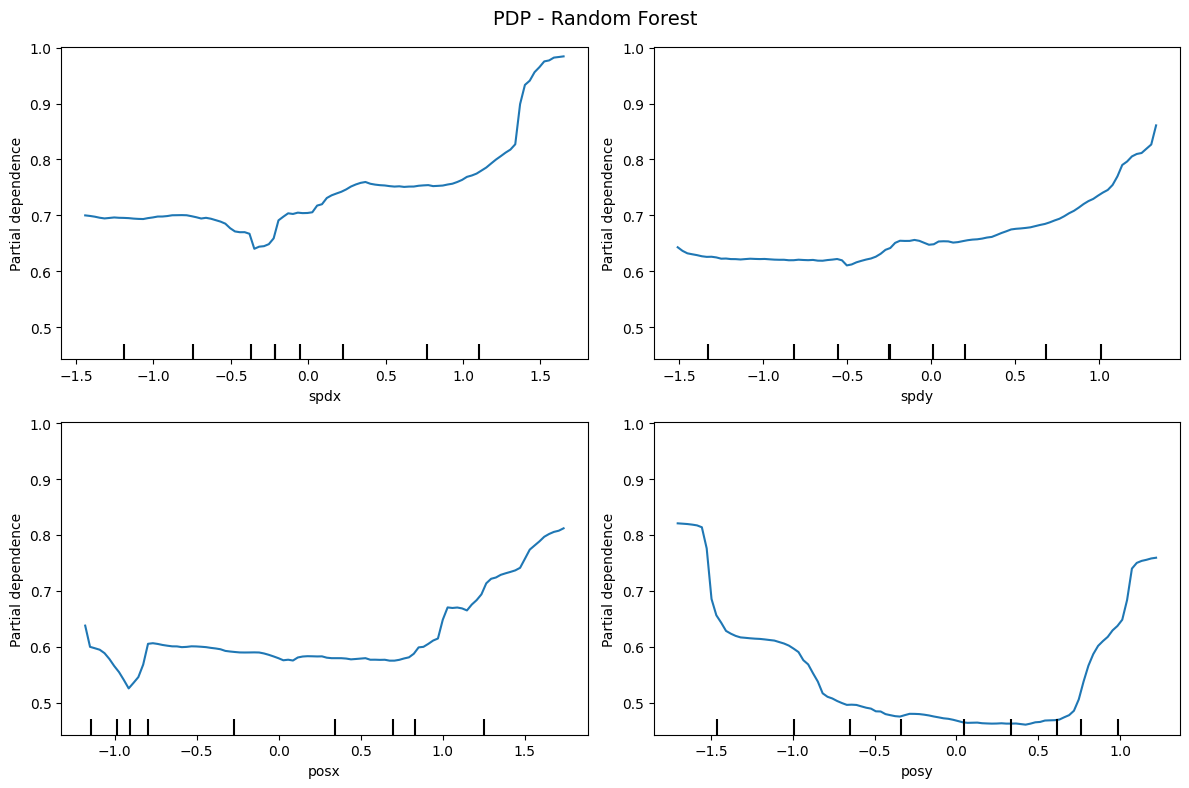

  Temps : 64s (1.1 min)
PDP pour Decision Tree...


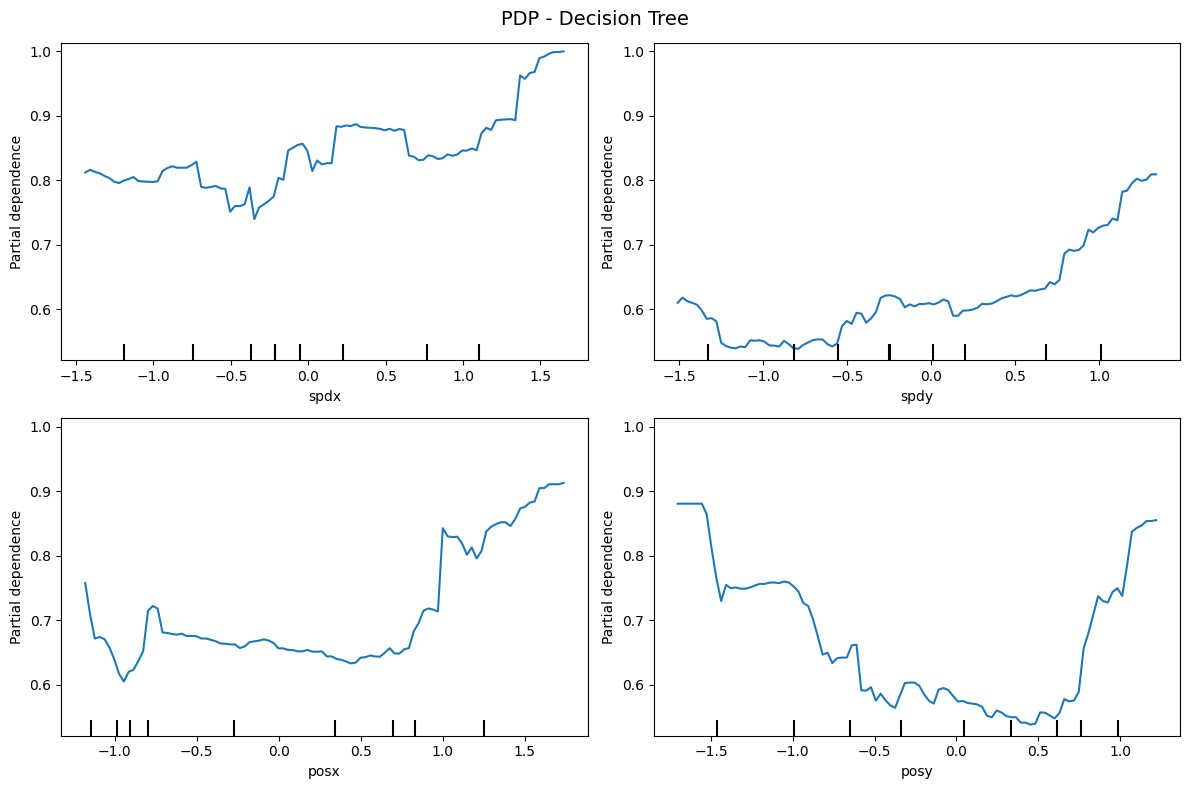

  Temps : 1s (0.0 min)
PDP pour DNN...


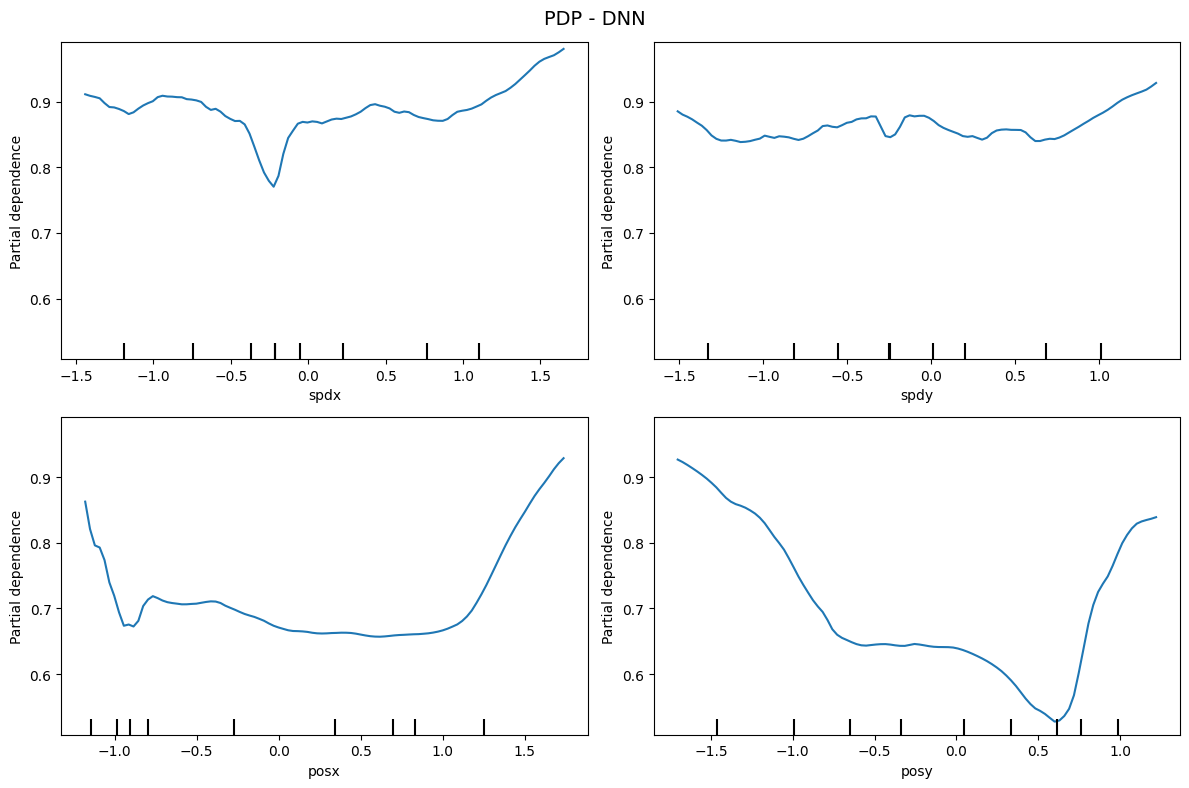

  Temps : 0s (0.0 min)


In [10]:
from sklearn.inspection import PartialDependenceDisplay

top_features = ['spdx', 'spdy', 'posx', 'posy']
top_features_idx = [feature_names.index(f) for f in top_features]

pdp_results = {}

for name, model in models.items():
    print(f'PDP pour {name}...')
    start = time.time()
    
    X_pdp = X_test.sample(n=500, random_state=42)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    display = PartialDependenceDisplay.from_estimator(
        model,
        X_pdp,
        features=top_features_idx,
        feature_names=feature_names,
        ax=axes[:len(top_features)],
        n_jobs=-1
    )
    
   
    pdp_results[name] = {
        'features': top_features,
        'pd_results': [(pd.average, pd.grid_values) 
                       for pd in display.pd_results]
    }
    
    
    
    plt.suptitle(f'PDP - {name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../figures/pdp_{name.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    elapsed = time.time() - start
    print(f'  Temps : {elapsed:.0f}s ({elapsed/60:.1f} min)')


with open('../models/pdp_results.pkl', 'wb') as f:
    pickle.dump(pdp_results, f)



DICE pour Random Forest...


100%|██████████| 1/1 [00:59<00:00, 59.49s/it]


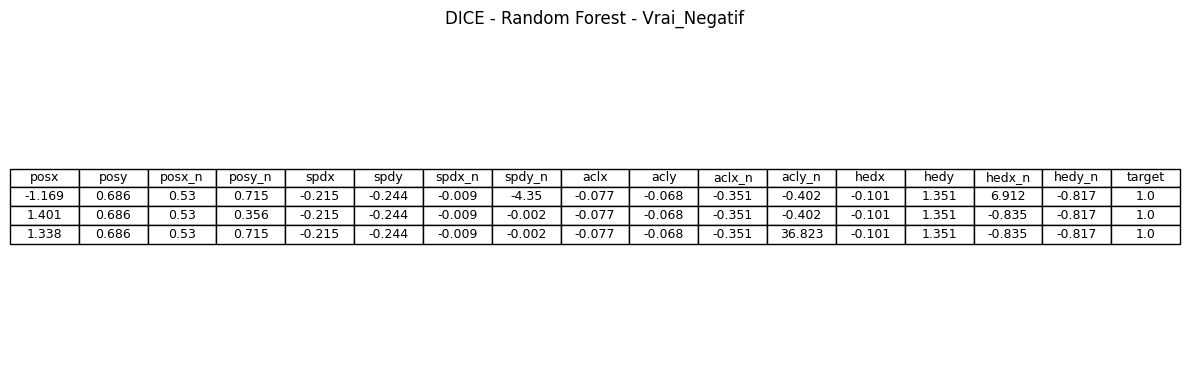

100%|██████████| 1/1 [00:59<00:00, 59.05s/it]


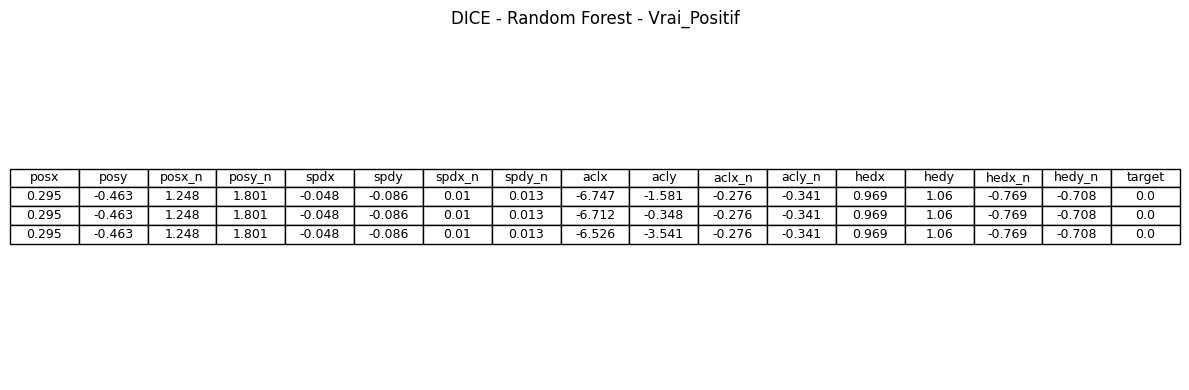

100%|██████████| 1/1 [01:02<00:00, 62.02s/it]


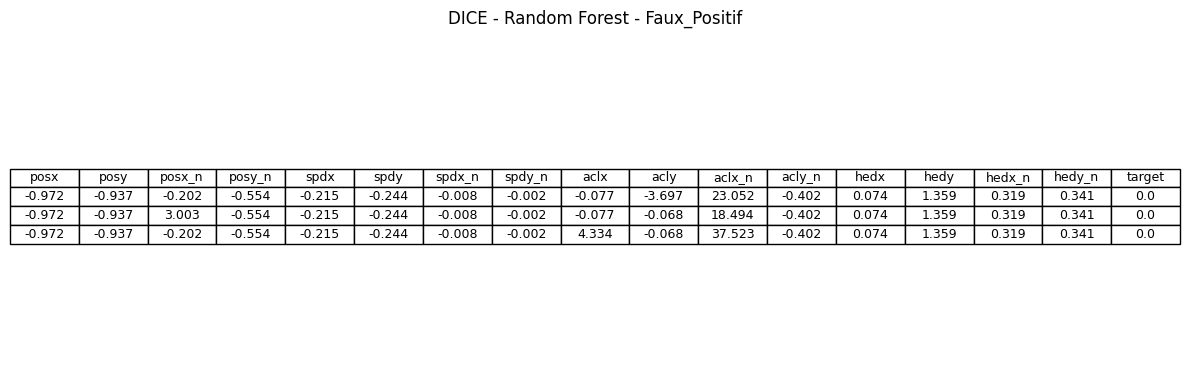

100%|██████████| 1/1 [00:42<00:00, 42.32s/it]


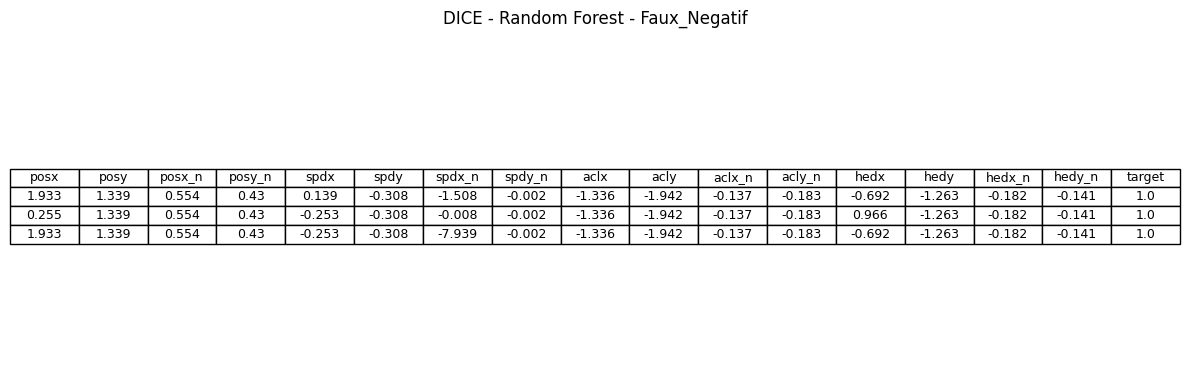

  Temps : 229s (3.8 min)
DICE pour Decision Tree...


100%|██████████| 1/1 [00:59<00:00, 59.48s/it]


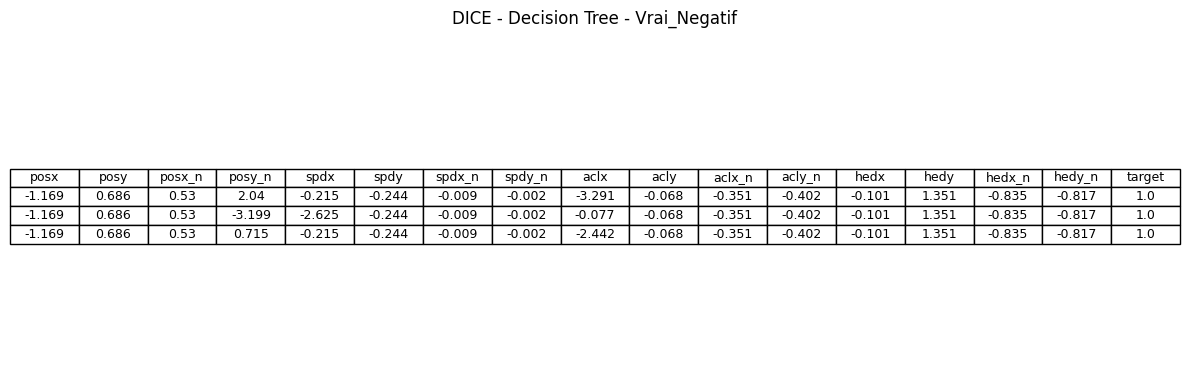

100%|██████████| 1/1 [00:58<00:00, 58.25s/it]


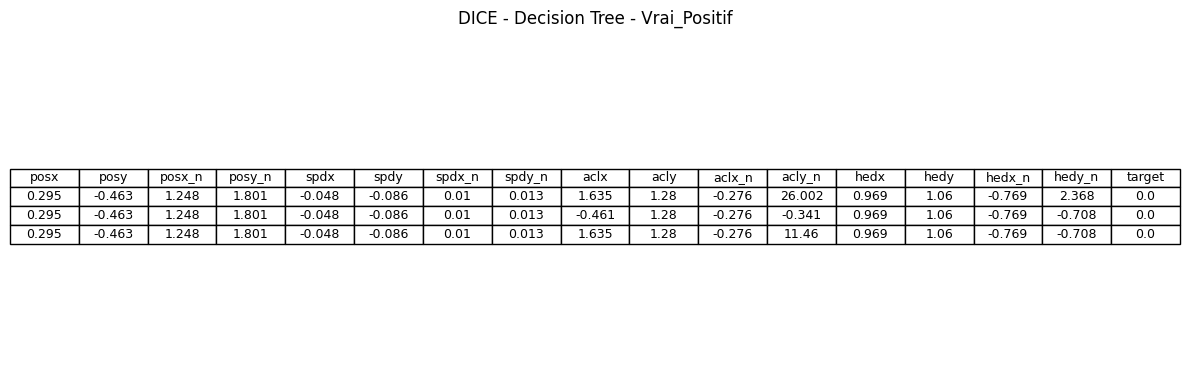

100%|██████████| 1/1 [01:08<00:00, 68.84s/it]


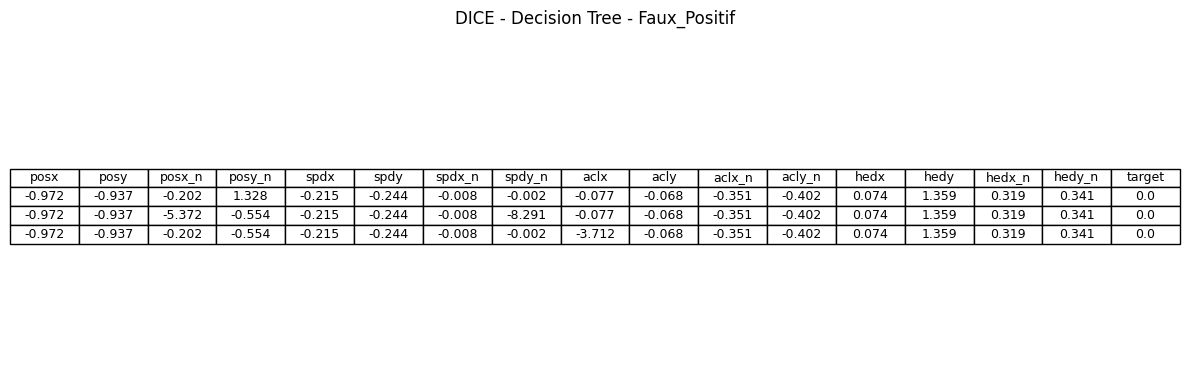

100%|██████████| 1/1 [01:06<00:00, 66.30s/it]


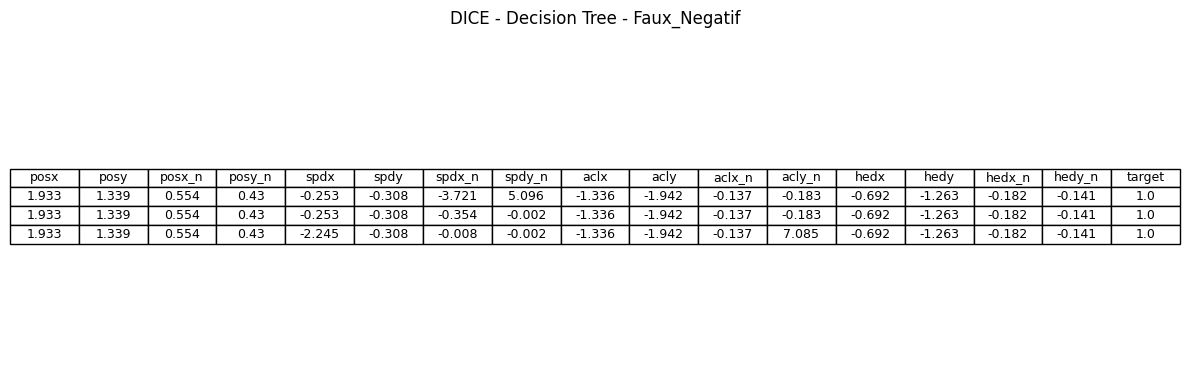

  Temps : 260s (4.3 min)
DICE pour DNN...


100%|██████████| 1/1 [00:59<00:00, 59.29s/it]


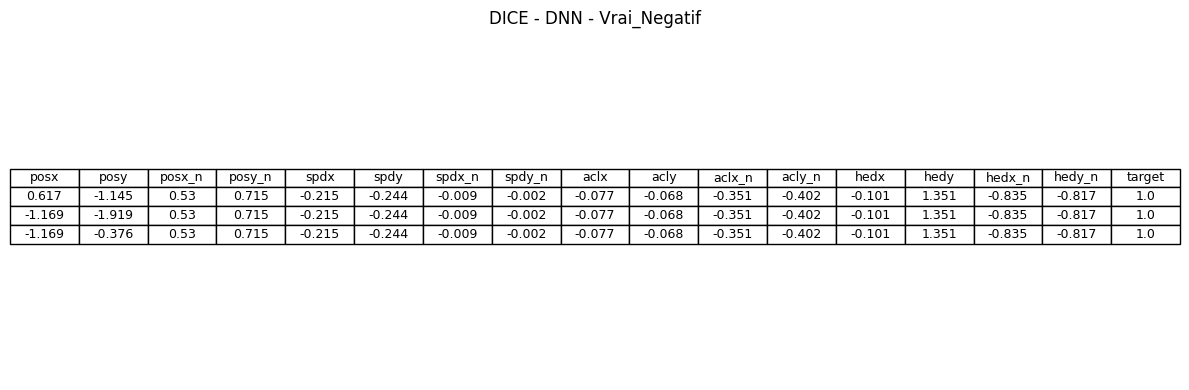

100%|██████████| 1/1 [01:01<00:00, 61.68s/it]


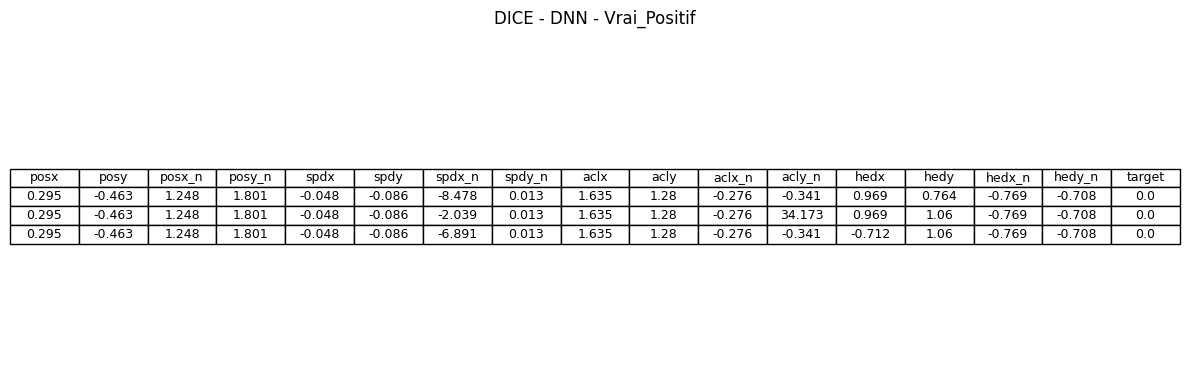

100%|██████████| 1/1 [00:44<00:00, 44.30s/it]


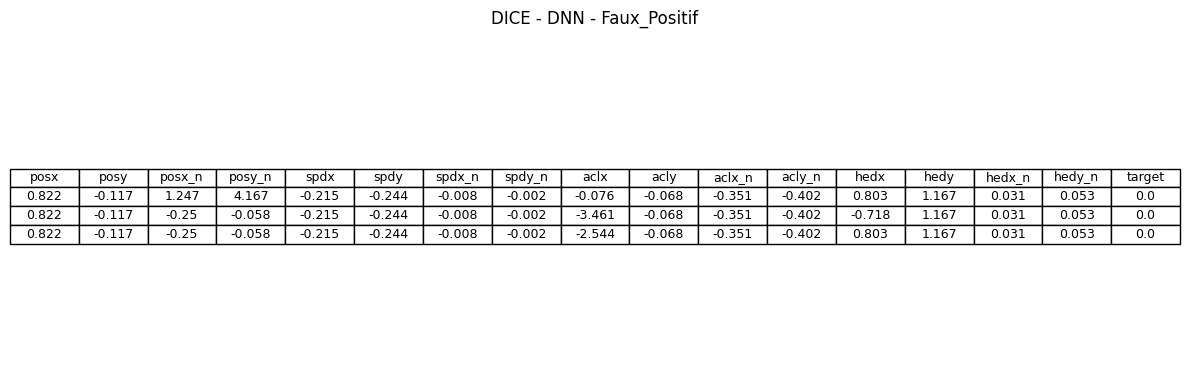

100%|██████████| 1/1 [00:40<00:00, 40.99s/it]


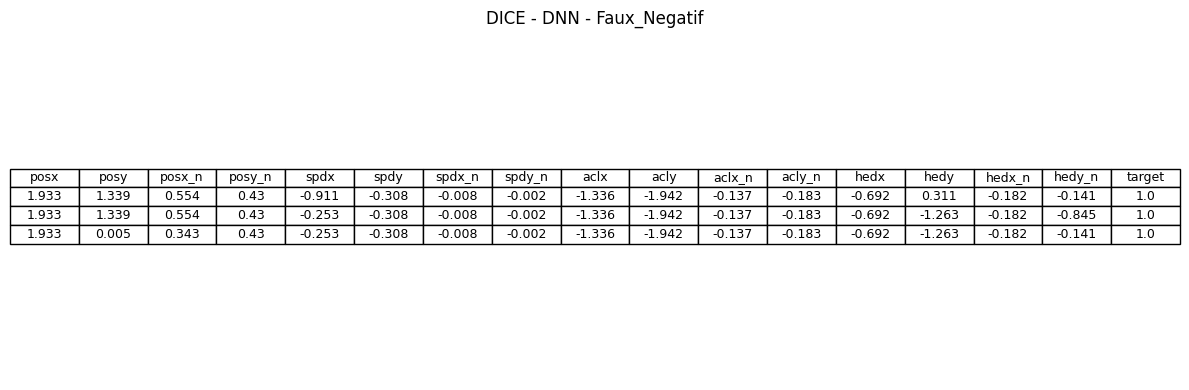

  Temps : 214s (3.6 min)


In [6]:
import dice_ml
from dice_ml import Dice
import time


d = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train_binary.rename('target')], axis=1),
    continuous_features=feature_names,
    outcome_name='target'
)

dice_results = {}

for name, model in models.items():
    print(f'DICE pour {name}...')
    dice_results[name] = {}
    start = time.time()
    
    # Créer le modèle DICE
    m = dice_ml.Model(model=model, backend='sklearn')
    exp = Dice(d, m, method='random')
    
    X_local = X_test.sample(n=1000, random_state=42)
    y_local = y_test_binary.loc[X_local.index]
    y_pred_local = model.predict(X_local)
    
    observations = {
        'Vrai_Negatif': X_local[(y_pred_local == 0) & (y_local.values == 0)].iloc[[0]],
        'Vrai_Positif': X_local[(y_pred_local == 1) & (y_local.values == 1)].iloc[[0]],
        'Faux_Positif': X_local[(y_pred_local == 1) & (y_local.values == 0)].iloc[[0]],
        'Faux_Negatif': X_local[(y_pred_local == 0) & (y_local.values == 1)].iloc[[0]]
    }
    
    for obs_name, obs in observations.items():
        pred = model.predict(obs)[0]
        desired_class = str(1 - int(pred))
        
        cf = exp.generate_counterfactuals(
            obs,
            total_CFs=3,
            desired_class="opposite"
        )
        
        dice_results[name][obs_name] = cf
        
        
        plt.figure(figsize=(12, 4))
        cf_df = cf.cf_examples_list[0].final_cfs_df
        plt.title(f'DICE - {name} - {obs_name}')
        plt.axis('off')
        plt.table(
            cellText=cf_df.round(3).values,
            colLabels=cf_df.columns,
            cellLoc='center',
            loc='center'
        )
        plt.tight_layout()
        plt.savefig(f'../figures/dice_{name.lower().replace(" ", "_")}_{obs_name}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        
    
    elapsed = time.time() - start
    print(f'  Temps : {elapsed:.0f}s ({elapsed/60:.1f} min)')

with open('../models/dice_results.pkl', 'wb') as f:
    pickle.dump(dice_results, f)
